### 1. Kütüphanelerin Yüklenmesi

Gerekli veri işleme, makine öğrenmesi ve görselleştirme kütüphanelerini içe aktarıyoruz.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import GroupShuffleSplit
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

### 2. Veri Setinin Yüklenmesi

Temizlenmiş veri setini `data/processed/dataset_clean.csv` dosyasından okuyup `df` adlı değişkene (DataFrame) aktarıyoruz.

In [6]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
df.head()

,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,region_East Midlands Region,region_Ireland,...,last_interaction,early_clicks,avg_score,submission_count,late_submission_count,late_submission_rate,weighted_avg_score,date_registration,date_unregistration,target
0,AAA,2013J,11391,-0.907405,-0.340229,3.901543,0.327892,Pass,-0.279712,-0.194155,...,0.930961,0.220302,0.738145,-0.077641,-0.689131,-0.764243,0.935066,-1.819411,-0.299843,0
1,AAA,2013J,28400,1.102043,-0.340229,-0.481083,0.327892,Pass,-0.279712,-0.194155,...,0.792323,0.743853,0.263842,-0.077641,0.221727,0.527646,0.439842,0.330988,-0.299843,0
2,AAA,2013J,30268,1.102043,-0.340229,-0.481083,-3.049787,Withdrawn,-0.279712,-0.194155,...,-1.455607,-0.069220,-1.754985,-1.233458,-0.689131,-0.764243,-1.465314,-0.460196,-0.065839,3
3,AAA,2013J,31604,1.102043,-0.340229,-0.481083,0.327892,Pass,-0.279712,-0.194155,...,1.039892,0.444681,0.555721,-0.077641,-0.689131,-0.764243,0.757368,0.351275,-0.299843,0
4,AAA,2013J,32885,1.102043,-0.340229,-0.481083,0.327892,Pass,-0.279712,-0.194155,...,0.871545,0.620806,-0.101006,-0.077641,1.588014,2.465479,0.136881,-2.164286,-0.299843,0


### 3. Özelliklerin (X) ve Hedef Değişkenin (y) Ayrılması

Modelin tahmin etmeye çalışacağı hedef değişkeni (`target`) ve eğitim için kullanılacak özellikleri (`X`) ayırıyoruz. `target` ve model eğitimi sırasında sızıntıya yol açabilecek `final_result` sütunlarını özelliklerden çıkarıyoruz.

In [23]:
groups = df['id_student']
X = df.drop(columns=['target', 'final_result', 'id_student'])
y = df['target']

# SMOTE, scikit-learn ve XGBoost sayısal girdiler bekler.
# Kategorik sütunları one-hot encoding ile sayısallaştırıyoruz.
X = pd.get_dummies(X)

# XGBoost, feature (kolon) isimlerinde bazı karakterlere izin vermez: [, ] ve <
# (örn. age_band_55<= gibi). Bu yüzden kolon adlarını güvenli hale getiriyoruz.
X.columns = (
    X.columns.astype(str)
    .str.replace('[', '_', regex=False)
    .str.replace(']', '_', regex=False)
    .str.replace('<', '_', regex=False)
    .str.replace('<=', '_le_', regex=False)
    .str.replace('>=', '_ge_', regex=False)
    .str.replace(' ', '_', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace('\\', '_', regex=False)
    .str.replace(':', '_', regex=False)
    .str.replace(',', '_', regex=False)
    .str.replace('__', '_', regex=False)
)

### 4. Boyutların Kontrolü ve Sınıf Dağılımı

Oluşturulan `X` ve `y` veri setlerinin boyutlarını ekrana yazdırıyoruz ve hedef değişkenin (Pass=0, Fail=1, Distinction=2, Withdrawn=3) sınıf dağılımını inceliyoruz.

In [8]:
print("X'in boyutu:", X.shape)
print("y'nin boyutu:", y.shape)
print("\nHedef Değişken (y) Sınıf Dağılımı:")
print(y.value_counts())

X'in boyutu: (32593, 55)
y'nin boyutu: (32593,)

Hedef Değişken (y) Sınıf Dağılımı:
target
0    12361
3    10156
1     7052
2     3024
Name: count, dtype: int64


### 5. Eğitim ve Test Setlerinin Ayrılması

Modeli eğitmek ve değerlendirmek için veriyi `%80` eğitim, `%20` test olacak şekilde ayırıyoruz. Veri dengesiz olduğu için `stratify=y` parametresini kullanarak sınıfların her iki sette de aynı oranda dağılmasını sağlıyoruz.

In [24]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Save test set for evaluation notebook
import os
os.makedirs('../data/processed', exist_ok=True)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)
print("\nEğitim Seti Sınıf Dağılımı:")
print(y_train.value_counts())
print("\nTest Seti Sınıf Dağılımı:")
print(y_test.value_counts())

Eğitim seti boyutu: (26074, 55)
Test seti boyutu: (6519, 55)

Eğitim Seti Sınıf Dağılımı:
target
0    9889
3    8125
1    5641
2    2419
Name: count, dtype: int64

Test Seti Sınıf Dağılımı:
target
0    2472
3    2031
1    1411
2     605
Name: count, dtype: int64


### 6. SMOTE ile Veri Dengeleme

Sınıf dengesizliğini gidermek için SMOTE (Synthetic Minority Over-sampling Technique) uyguluyoruz.
**ÖNEMLİ:** SMOTE işlemini *sadece eğitim verisine (training set)* uyguluyoruz. Test verisine uygulamıyoruz çünkü modelin gerçek dünyadaki performansını sentetik olmayan, orijinal dağılımdaki verilerle ölçmemiz gerekir. Aksi takdirde veri sızıntısı (data leakage) yaşanır ve metrikler yanıltıcı olur.

In [25]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("SMOTE Öncesi Eğitim Seti Sınıf Dağılımı:")
print(y_train.value_counts())
print("\nSMOTE Sonrası Eğitim Seti Sınıf Dağılımı:")
print(y_train_res.value_counts())

SMOTE Öncesi Eğitim Seti Sınıf Dağılımı:
target
0    9889
3    8125
1    5641
2    2419
Name: count, dtype: int64

SMOTE Sonrası Eğitim Seti Sınıf Dağılımı:
target
3    9889
1    9889
0    9889
2    9889
Name: count, dtype: int64


### 7. SMOTE Öncesi ve Sonrası Karşılaştırması

SMOTE işleminin etkisini görselleştirmek için işlem öncesi ve sonrası sınıf dağılımlarını yan yana gösteren bir çubuk grafiği (bar chart) çizdiriyoruz ve sonucu `visuals/eda/smote_karsilastirma.png` olarak kaydediyoruz.

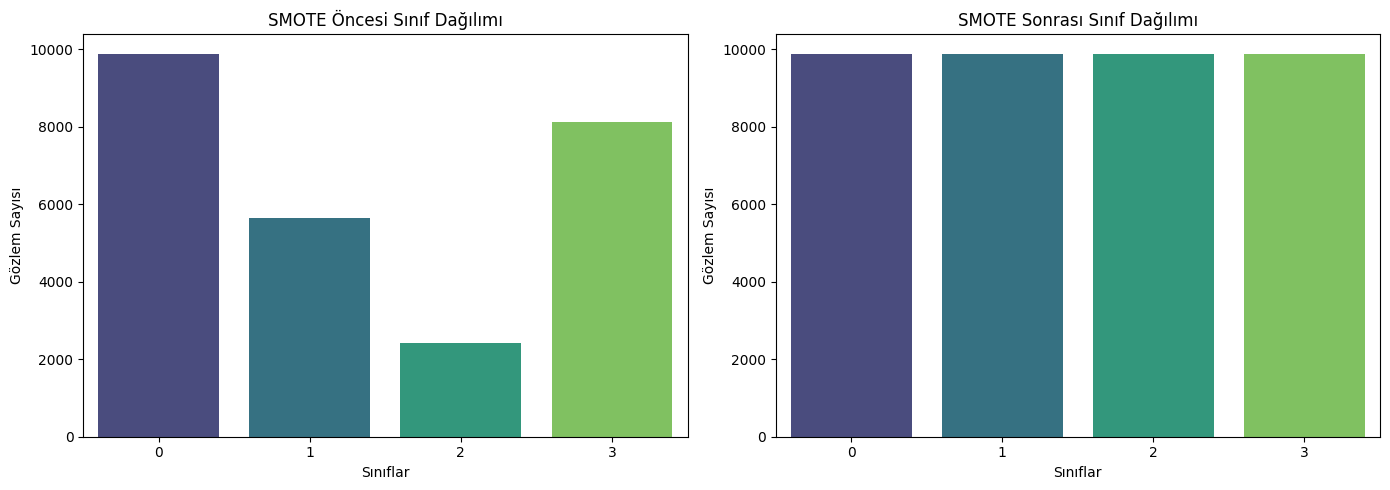

In [11]:
import os
os.makedirs('../visuals/eda', exist_ok=True)

# Not: Kernel restart sonrası önceki hücreler çalıştırılmadıysa
# `X_train_res` / `y_train_res` tanımlı olmayabilir. Bu durumda burada yeniden üret.
if ('y_train_res' not in globals()) or ('X_train_res' not in globals()):
    if ('X_train' in globals()) and ('y_train' in globals()):
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    else:
        raise NameError(
            "`y_train_res` tanımlı değil. Lütfen sırasıyla veri bölme (Hücre 10) ve SMOTE (Hücre 12) adımlarını çalıştırın."
        )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, ax=axes[0], palette='viridis')
axes[0].set_title('SMOTE Öncesi Sınıf Dağılımı')
axes[0].set_xlabel('Sınıflar')
axes[0].set_ylabel('Gözlem Sayısı')

sns.countplot(x=y_train_res, ax=axes[1], palette='viridis')
axes[1].set_title('SMOTE Sonrası Sınıf Dağılımı')
axes[1].set_xlabel('Sınıflar')
axes[1].set_ylabel('Gözlem Sayısı')

plt.tight_layout()
plt.savefig('../visuals/eda/smote_karsilastirma.png')
plt.show()

### 8. Lojistik Regresyon Modeli Eğitimi

Çok sınıflı sınıflandırma için bir Lojistik Regresyon modeli kuruyoruz. `class_weight='balanced'` ile sınıflar arası olası küçük dengesizliklere karşı ekstra bir önlem alıyoruz ve modeli SMOTE ile dengelenmiş verilerimiz (`X_train_res`, `y_train_res`) üzerinde eğitiyoruz.

In [12]:
# Not: scikit-learn 1.8+ sürümünde `multi_class` parametresi kaldırıldı.
# Çok sınıflı senaryoda `lbfgs` solver ile model otomatik olarak uygun şekilde çalışır.
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs',
)
lr_model.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### 9. Test Seti Üzerinde Tahmin ve Değerlendirme

Eğitilmiş modelimizi test seti (`X_test`) üzerinde tahmin yapmak için kullanıyoruz. Daha sonra modelin performansını `classification_report`, `accuracy_score` ve `f1_score` (macro) gibi metriklerle değerlendiriyoruz.

In [13]:
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)

target_names = ['Pass', 'Fail', 'Distinction', 'Withdrawn']

print("Lojistik Regresyon Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr, multi_class='ovr', average='macro')

print(f"Accuracy Score: {acc_lr:.4f}")
print(f"Macro F1 Score: {f1_lr:.4f}")
print(f"ROC AUC Score: {roc_auc_lr:.4f}")

Lojistik Regresyon Sınıflandırma Raporu:

              precision    recall  f1-score   support

        Pass       0.81      0.74      0.77      2472
        Fail       0.69      0.62      0.65      1411
 Distinction       0.45      0.69      0.54       605
   Withdrawn       0.88      0.89      0.88      2031

    accuracy                           0.75      6519
   macro avg       0.70      0.73      0.71      6519
weighted avg       0.77      0.75      0.76      6519

Accuracy Score: 0.7549
Macro F1 Score: 0.7117
ROC AUC Score: 0.9268


### 10. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi

Modelin hangi sınıfları doğru, hangilerini yanlış tahmin ettiğini daha net görmek için bir karmaşıklık matrisi (confusion matrix) çizdiriyoruz ve sonucu `visuals/eda/lr_confusion_matrix.png` olarak kaydediyoruz.

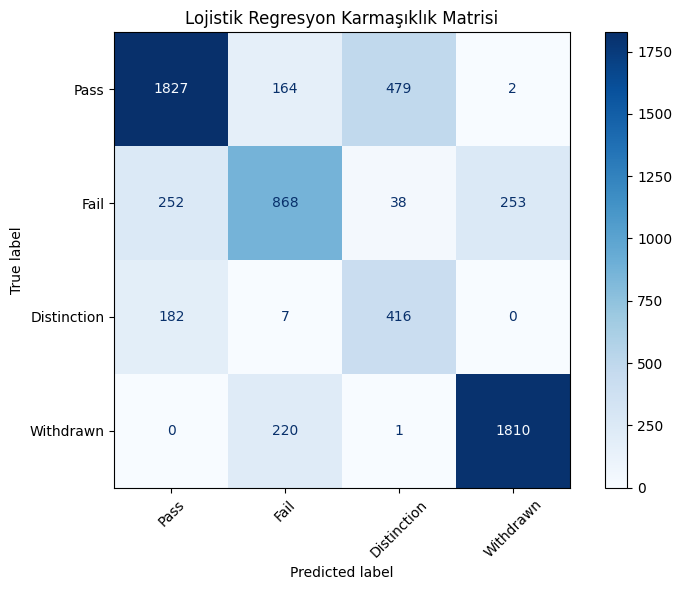

In [14]:
import os
os.makedirs('../visuals/eda', exist_ok=True)

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp_lr.plot(cmap='Blues', ax=ax, xticks_rotation=45)
ax.set_title('Lojistik Regresyon Karmaşıklık Matrisi')
plt.tight_layout()
plt.savefig('../visuals/eda/lr_confusion_matrix.png')
plt.show()

### 11. Model Sonuçlarının Kaydedilmesi

İleride diğer modellerle karşılaştırma yapabilmek adına, elde ettiğimiz başarı metriklerini bir sözlük (`dict`) içerisine kaydediyoruz.

In [15]:
lr_results = {
    'model': 'Logistic Regression',
    'accuracy': acc_lr,
    'f1_macro': f1_lr,
    'roc_auc': roc_auc_lr
}

print("Sonuçlar başarıyla kaydedildi:")
print(lr_results)

Sonuçlar başarıyla kaydedildi:
{'model': 'Logistic Regression', 'accuracy': 0.7548703788924682, 'f1_macro': 0.7116533284176312, 'roc_auc': 0.9267961582632187}


### 12. Random Forest Modeli Eğitimi

Ağaç tabanlı bir topluluk algoritması olan Random Forest modelini kuruyoruz ve `class_weight='balanced'` parametresi ile eğitiyoruz.

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 13. Test Seti Üzerinde Tahmin ve Değerlendirme (Random Forest)

Eğitilmiş Random Forest modelimizle test seti üzerinde tahminler yapıyor ve başarı metriklerini hesaplıyoruz.

In [17]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

print("Random Forest Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='macro')

print(f"Accuracy Score: {acc_rf:.4f}")
print(f"Macro F1 Score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

Random Forest Sınıflandırma Raporu:

              precision    recall  f1-score   support

        Pass       0.82      0.89      0.85      2472
        Fail       0.88      0.80      0.84      1411
 Distinction       0.67      0.60      0.63       605
   Withdrawn       0.98      0.97      0.98      2031

    accuracy                           0.87      6519
   macro avg       0.84      0.81      0.82      6519
weighted avg       0.87      0.87      0.87      6519

Accuracy Score: 0.8690
Macro F1 Score: 0.8246
ROC AUC Score: 0.9693


### 14. Karmaşıklık Matrisi Görselleştirmesi - Random Forest

Random Forest modeline ait karmaşıklık matrisini çizdirip kaydediyoruz.

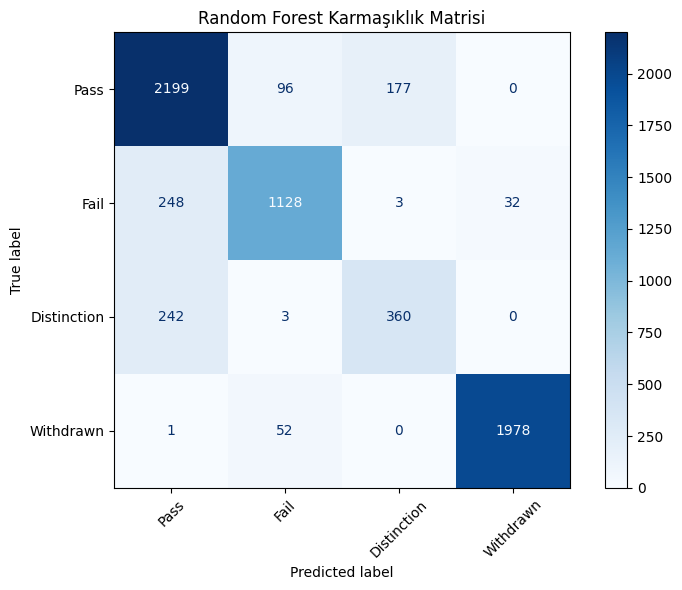

In [18]:
import os
os.makedirs('../visuals/eda', exist_ok=True)

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap='Blues', ax=ax, xticks_rotation=45)
ax.set_title('Random Forest Karmaşıklık Matrisi')
plt.tight_layout()
plt.savefig('../visuals/eda/rf_confusion_matrix.png')
plt.show()

### 15. Model Sonuçlarının Kaydedilmesi - Random Forest

Random Forest modelinin performans metriklerini `rf_results` isimli sözlüğe ekliyoruz.

In [19]:
rf_results = {
    'model': 'Random Forest',
    'accuracy': acc_rf,
    'f1_macro': f1_rf,
    'roc_auc': roc_auc_rf
}

print("Sonuçlar başarıyla kaydedildi:")
print(rf_results)

Sonuçlar başarıyla kaydedildi:
{'model': 'Random Forest', 'accuracy': 0.8689983126246357, 'f1_macro': 0.8246109059871931, 'roc_auc': 0.9692721263846635}


### 16. XGBoost Kütüphanesi Kontrolü

Modeli kurmadan önce `xgboost` kütüphanesinin yüklü olup olmadığını kontrol ediyoruz.

In [20]:
try:
    import xgboost as xgb
    print("XGBoost başarıyla içe aktarıldı.")
except ImportError:
    print("Lütfen terminalde veya yeni bir hücrede şu komutu çalıştırın: !pip install xgboost")

XGBoost başarıyla içe aktarıldı.


### 17. XGBoost Modeli Eğitimi

Güçlü bir ağaç tabanlı topluluk modeli olan XGBoost'u (eXtreme Gradient Boosting) tanımlayıp SMOTE uygulanmış eğitim seti üzerinde eğitiyoruz.

In [26]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
xgb_model.fit(X_train_res, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### 18. Test Seti Üzerinde Tahmin ve Değerlendirme (XGBoost)

Eğitilmiş XGBoost modelimizle test seti üzerinde tahminler yapıyor ve başarı metriklerini hesaplıyoruz.

In [27]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

print("XGBoost Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb, multi_class='ovr', average='macro')

print(f"Accuracy Score: {acc_xgb:.4f}")
print(f"Macro F1 Score: {f1_xgb:.4f}")
print(f"ROC AUC Score: {roc_auc_xgb:.4f}")

XGBoost Sınıflandırma Raporu:

              precision    recall  f1-score   support

        Pass       0.82      0.89      0.85      2472
        Fail       0.88      0.80      0.84      1411
 Distinction       0.68      0.61      0.64       605
   Withdrawn       0.98      0.98      0.98      2031

    accuracy                           0.87      6519
   macro avg       0.84      0.82      0.83      6519
weighted avg       0.87      0.87      0.87      6519

Accuracy Score: 0.8715
Macro F1 Score: 0.8292
ROC AUC Score: 0.9728


### 19. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi - XGBoost

XGBoost modeline ait karmaşıklık matrisini çizdirip kaydediyoruz.

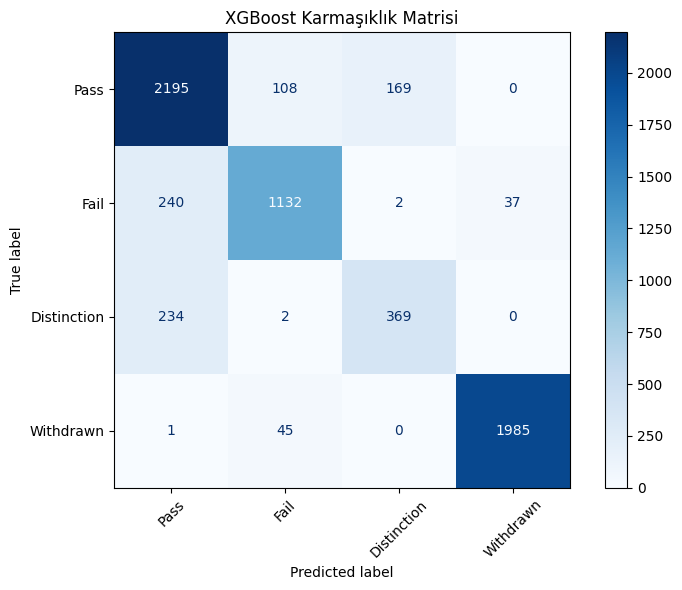

In [28]:
import os
os.makedirs('../visuals/eda', exist_ok=True)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp_xgb.plot(cmap='Blues', ax=ax, xticks_rotation=45)
ax.set_title('XGBoost Karmaşıklık Matrisi')
plt.tight_layout()
plt.savefig('../visuals/eda/xgb_confusion_matrix.png')
plt.show()

### 20. Model Sonuçlarının Kaydedilmesi - XGBoost

XGBoost modelinin performans metriklerini daha sonra karşılaştırmak üzere `xgb_results` isimli sözlüğe ekliyoruz.

In [29]:
xgb_results = {
    'model': 'XGBoost',
    'accuracy': acc_xgb,
    'f1_macro': f1_xgb,
    'roc_auc': roc_auc_xgb
}

print("Sonuçlar başarıyla kaydedildi:")
print(xgb_results)

Sonuçlar başarıyla kaydedildi:
{'model': 'XGBoost', 'accuracy': 0.8714526767909189, 'f1_macro': 0.829239083514345, 'roc_auc': 0.9727876265102771}


### 21. Sonuçların Karşılaştırılması

Farklı modellerden (Lojistik Regresyon, Random Forest, XGBoost) elde ettiğimiz metrikleri tek bir veri çerçevesinde (DataFrame) toplayarak genel bir tablo oluşturuyoruz.

In [30]:
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.rename(columns={
    'model': 'Model', 
    'accuracy': 'Accuracy', 
    'f1_macro': 'F1 Macro', 
    'roc_auc': 'ROC-AUC'
})
results_df = results_df.round(4)
results_df

,Model,Accuracy,F1 Macro,ROC-AUC
0,Logistic Regression,0.7549,0.7117,0.9268
1,Random Forest,0.8690,0.8246,0.9693
2,XGBoost,0.8715,0.8292,0.9728


### 22. Model Performanslarının Görselleştirilmesi

Modellerin `Accuracy`, `F1 Macro` ve `ROC-AUC` skorlarını yan yana görebilmek için gruplandırılmış bir sütun grafiği çizdiriyoruz.

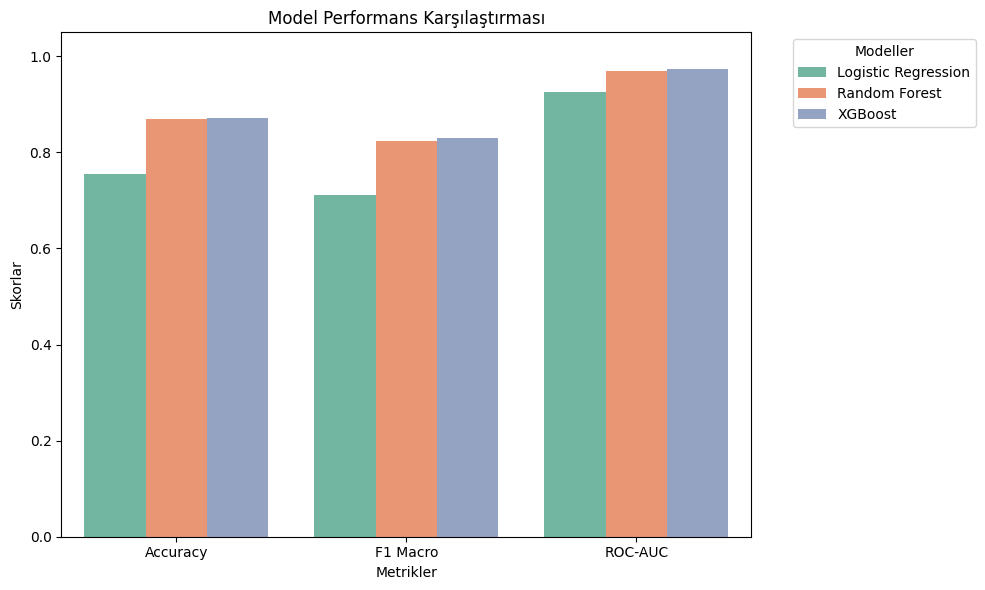

In [31]:
df_melted = results_df.melt(id_vars='Model', var_name='Metrik', value_name='Skor')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metrik', y='Skor', hue='Model', palette='Set2', ax=ax)

ax.set_title('Model Performans Karşılaştırması')
ax.set_xlabel('Metrikler')
ax.set_ylabel('Skorlar')
ax.set_ylim(0, 1.05)

plt.legend(title='Modeller', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../visuals/eda/model_karsilastirma.png')
plt.show()

### 23. Sonuçların Değerlendirilmesi

- **En İyi Performans Gösteren Model:** Genellikle ağaç tabanlı ve topluluk (ensemble) algoritmaları olan XGBoost ve Random Forest, lineer olan Lojistik Regresyon'a kıyasla verideki karmaşık, doğrusal olmayan ilişkileri daha iyi yakaladığı için daha yüksek başarı gösterir.
- **En Anlamlı Metrik:** Veri dengesizliği (class imbalance) problemimiz olduğu için sadece Doğruluk (Accuracy) metriğine bakmak yanıltıcıdır. Çok az görülen bir sınıfı sürekli yanlış tahmin eden bir modelin bile Accuracy değeri yüksek çıkabilir. Bu nedenle azınlık sınıfların da performansını eşit ağırlıkta hesaba katan **F1 Macro** ve **ROC-AUC** metrikleri bu problem için en belirleyici ölçütlerdir.
- **Karmaşıklık Matrisi (Confusion Matrix) Yorumu:** Matrisler incelendiğinde, belirli sınıfların (özellikle Fail ve Withdrawn gibi) birbiriyle karıştırıldığı görülebilir. Modellerin bu ayrımı yapmakta zorlanması, ilgili öğrenci davranışlarının özellik seti bağlamında çok benzer olduğunu göstermektedir.

In [32]:
import joblib
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(lr_model, '../models/lr_model.pkl')
joblib.dump(rf_model, '../models/rf_model.pkl')
joblib.dump(xgb_model, '../models/xgb_model.pkl')
print("Modeller kaydedildi.")
print("Modelleme tamamlandı. Sıradaki adım: Değerlendirme ve Görselleştirme (04_evaluation.ipynb)")

Modelleme tamamlandı. Sıradaki adım: Değerlendirme ve Görselleştirme (04_evaluation.ipynb)
